In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib import cm
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import seaborn as sns

import os
import sys
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
from plot_phases import plot_cont_phase_diagram, plot_discrete_phase_diagram, plot_phase_line

In [3]:
# === Configuration ===
data_root = Path("SQUARE")  # adjust to where your results live
output_root = Path("combined_results")
output_root.mkdir(exist_ok=True, parents=True)

# Known parameter arrays
FLEX_STRENGTH_values = [
    0.005, 0.01, 0.02, 0.03, 0.04, 0.050, 0.06, 0.07, 0.08, 0.09,
    0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400,
    0.450, 0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800,
    0.850, 0.900, 0.950, 0.980, 0.985, 0.990, 0.995, 1.000
]

S_values = [
    0.01, 0.02, 0.04, 0.06, 0.08, 0.15, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.6, 2, 4, 8, 16
]

# start = 0.08
# end = 0.4
# n = 500
# step = (end - start) / (n - 1)
# S_values = [start + i * step for i in range(n)]

# S_values = np.arange(0.08, 0.40, step=0.01)


# --- Helpers ---

def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.3g}"
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)

with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root / f"flex{fmt_folder_val(F)}"
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}, {pattern} {f_dir}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv(output_root / "summary_square_final.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations: 100%|██████████████████████████████████████| 726/726 [02:48<00:00,  4.32it/s]


✅ Combined 726 parameter groups
📁 Results saved in: C:\Users\audso\GitHub\DHT-simulations-misinformation-propagation\N4096_new\combined_results


396     0.01
397     0.02
398     0.04
399     0.06
400     0.08
401     0.10
402     0.15
403     0.20
404     0.30
405     0.40
406     0.50
407     0.60
408     0.70
409     0.80
410     0.90
411     1.00
412     1.20
413     1.60
414     2.00
415     4.00
416     8.00
417    16.00
Name: S, dtype: float64


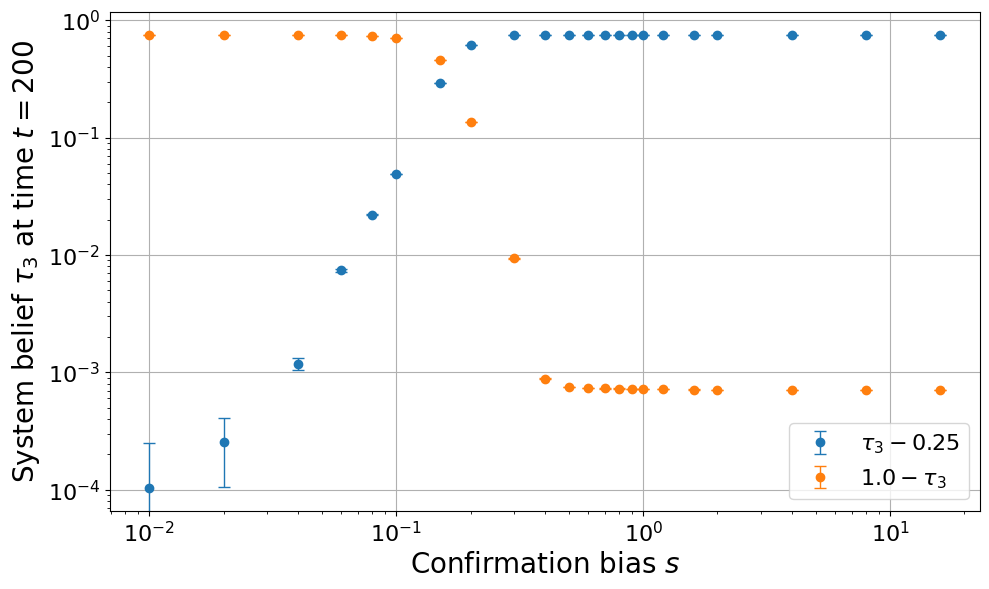

In [2]:
data_path = Path("combined_results/summary_square_final.csv")  # adjust if needed
df = pd.read_csv(data_path)

df2 = df[df['F']==0.5]
print(df2['S'])

plot_phase_line(df2, 'S', 'T3',  Path(f"test"), Path("plots"), "log", "log", inverse=False)

In [4]:
FLEX_STRENGTH_values = [
    1.000
]

S_values = [
    0.01, 0.02, 0.04
]
data_root = Path("SQUARE")  # adjust to where your results live
output_root = Path("nan_combined_results")
output_root.mkdir(exist_ok=True, parents=True)



def fmt_folder_val(x: float) -> str:
    """
    Format a float for folder name like:
    0.05 -> flex005, 0.1 -> flex01, 0.995 -> flex0995
    """
    if x == 1.0:
        return "10"
    return str(x).replace('.', '')

def fmt_val(x: float) -> str:
    """Format float for filename (S and F inside .npz)"""
    if x == 1.0:
        return "1"
    s = f"{x:.3g}"
    return s.replace('.', 'p')

def combine_arrays(arrs, stds, n=20):
    """Combine replicate means and stds across replicates."""
    arrs = np.stack(arrs)
    stds = np.stack(stds)
    K = arrs.shape[0]
    means = arrs.mean(axis=0)

    SS_within = ((n - 1) * stds**2).sum(axis=0)
    SS_between = (n * (arrs - means)**2).sum(axis=0)

    pooled_var = (SS_within + SS_between) / (K * n - 1)
    pooled_std = np.sqrt(pooled_var)
    return means, pooled_std


# --- Combination loop ---

summary_rows = []
total_tasks = len(FLEX_STRENGTH_values) * len(S_values)



with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
    for F in FLEX_STRENGTH_values:
        f_dir = data_root / f"flex{fmt_folder_val(F)}"
        if not f_dir.exists():
            tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
            pbar.update(len(S_values))
            continue

        for S in S_values:
            pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
            files = list(f_dir.glob(pattern))
            pbar.update(1)

            if not files:
                tqdm.write(f"⚠️  No files for S={S}, F={F}, {pattern} {f_dir}")
                continue

            data = [np.load(f) for f in files]
            keys = ["T0", "T1", "T2", "T3", "CD"]
            combined = {}

            for k in keys:
                means = [d[k] for d in data]
                stds = [d[f"{k}_std"] for d in data]
                m, s = combine_arrays(means, stds)
                combined[k] = m
                combined[f"{k}_std"] = s

            # Save combined time-series .npz
            out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
            np.savez_compressed(out_npz, **combined, S=S, F=F)

            # Store final-timestep summary
            final = {k: combined[k][-1] for k in keys}
            final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
            summary_rows.append({"S": S, "F": F, **final, **final_std})

# === Write summary CSV ===
df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
df.to_csv(output_root / "summary_square_final.csv", index=False)

print(f"\n✅ Combined {len(summary_rows)} parameter groups")
print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations: 100%|██████████████████████████████████████████| 3/3 [00:00<00:00,  4.83it/s]



✅ Combined 3 parameter groups
📁 Results saved in: C:\Users\audso\GitHub\DHT-simulations-misinformation-propagation\N4096_new\nan_combined_results


In [18]:
data =np.load(r"SQUARE\flex10\METRICS_DHT_N4096_SQUARE_S0p04_flex1_gaussian-stds075_T200_20sims_5.npz")
print(data.files)

print(data['T2'])

['T0', 'T1', 'T2', 'T3', 'T0_std', 'T1_std', 'T2_std', 'T3_std', 'CD', 'CD_std']
[0.24966552        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan    

In [ ]:
# FLEX_STRENGTH_values = [
#     1.000
# ]

# S_values = [
#     0.01, 0.02, 0.04
# ]

# data_root = Path("SQUARE")  # adjust to where your results live
# output_root = Path("nan_combined_results")
# output_root.mkdir(exist_ok=True, parents=True)

# with tqdm(total=total_tasks, desc="Combining simulations", ncols=100) as pbar:
#     for F in FLEX_STRENGTH_values:
#         f_dir = data_root / f"flex{fmt_folder_val(F)}"
#         if not f_dir.exists():
#             tqdm.write(f"⚠️  Missing folder for FLEX_STRENGTH={F} ({f_dir})")
#             pbar.update(len(S_values))
#             continue

#         for S in S_values:
#             pattern = f"*S{fmt_val(S)}_flex{fmt_val(F)}_*.npz"
#             files = list(f_dir.glob(pattern))
#             pbar.update(1)

#             if not files:
#                 tqdm.write(f"⚠️  No files for S={S}, F={F}, {pattern} {f_dir}")
#                 continue

#             data = [np.load(f) for f in files]
#             keys = ["T0", "T1", "T2", "T3", "CD"]
#             combined = {}

#             for k in keys:
#                 assert not np.isnan([d[k] for d in data])
#                 means = [d[k] for d in data]
#                 stds = [d[f"{k}_std"] for d in data]
#                 m, s = combine_arrays(means, stds)
#                 combined[k] = m
#                 combined[f"{k}_std"] = s

#             # Save combined time-series .npz
#             out_npz = output_root / f"COMBINED_S{fmt_val(S)}_F{fmt_val(F)}.npz"
#             np.savez_compressed(out_npz, **combined, S=S, F=F)

#             # Store final-timestep summary
#             final = {k: combined[k][-1] for k in keys}
#             final_std = {f"{k}_std": combined[f"{k}_std"][-1] for k in keys}
#             summary_rows.append({"S": S, "F": F, **final, **final_std})

# # === Write summary CSV ===
# df = pd.DataFrame(summary_rows).sort_values(["F", "S"])
# df.to_csv(output_root / "summary_square_final.csv", index=False)

# print(f"\n✅ Combined {len(summary_rows)} parameter groups")
# print(f"📁 Results saved in: {output_root.resolve()}")

Combining simulations:  33%|█████████████▋                           | 1/3 [00:00<00:00, 129.41it/s]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

<Figure size 1400x1000 with 0 Axes>

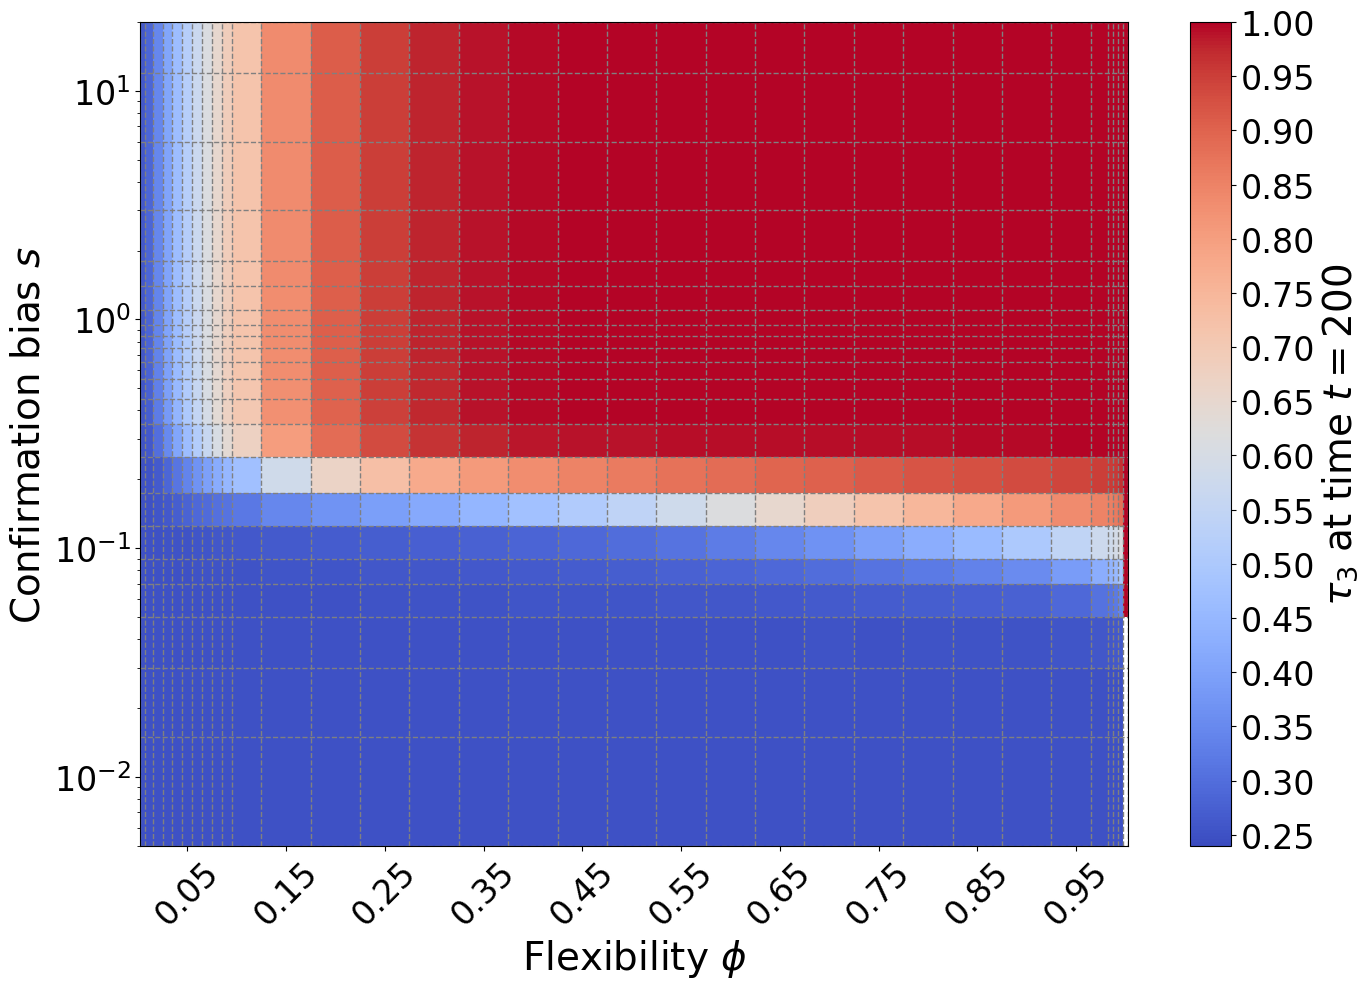

<Figure size 1400x1000 with 0 Axes>

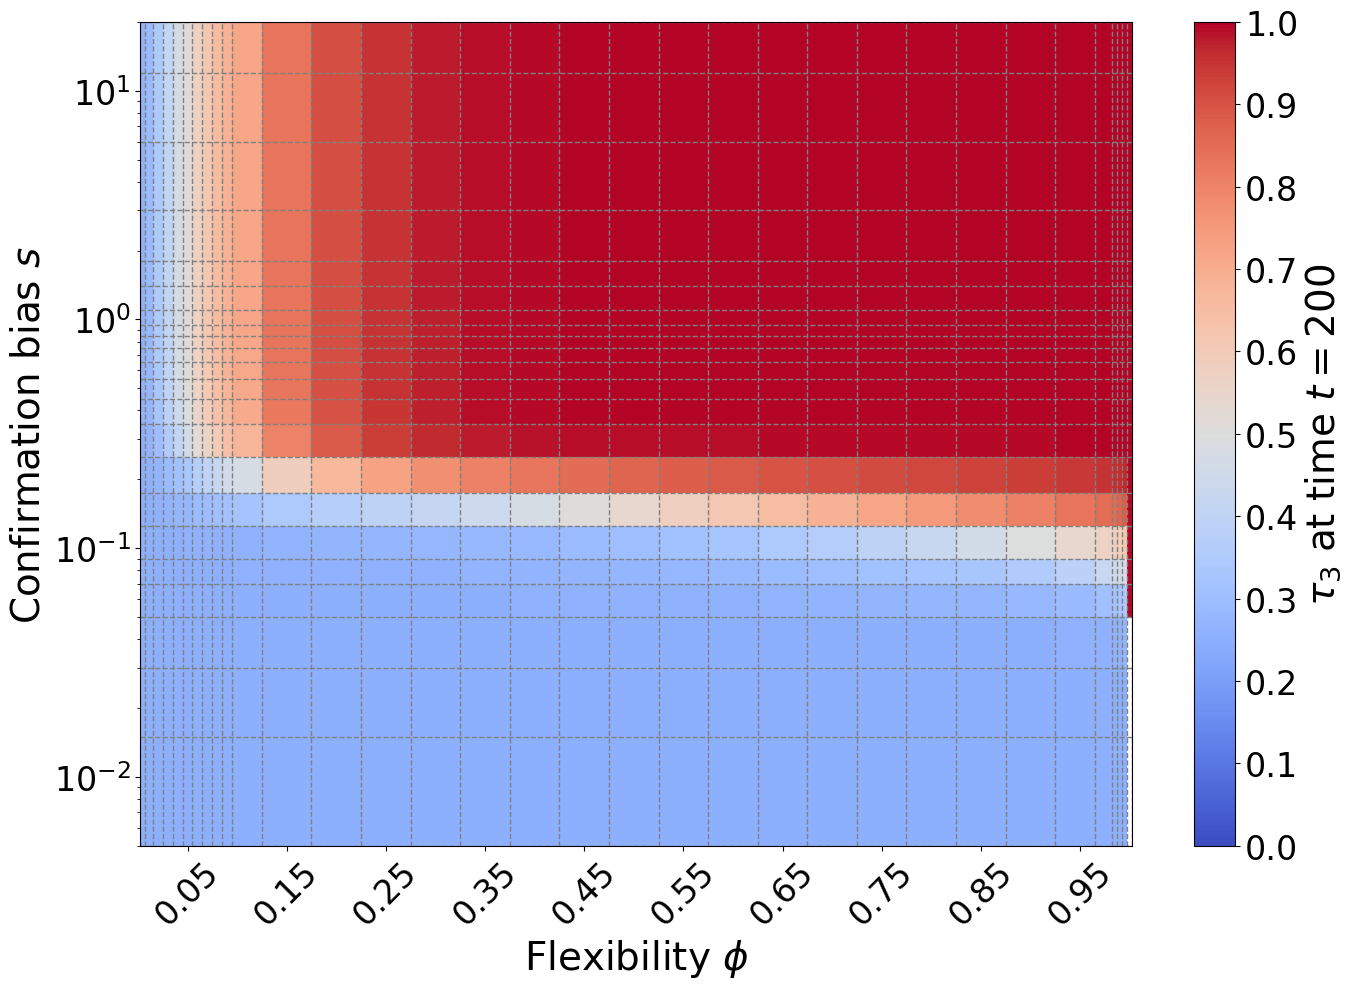

<Figure size 1400x1000 with 0 Axes>

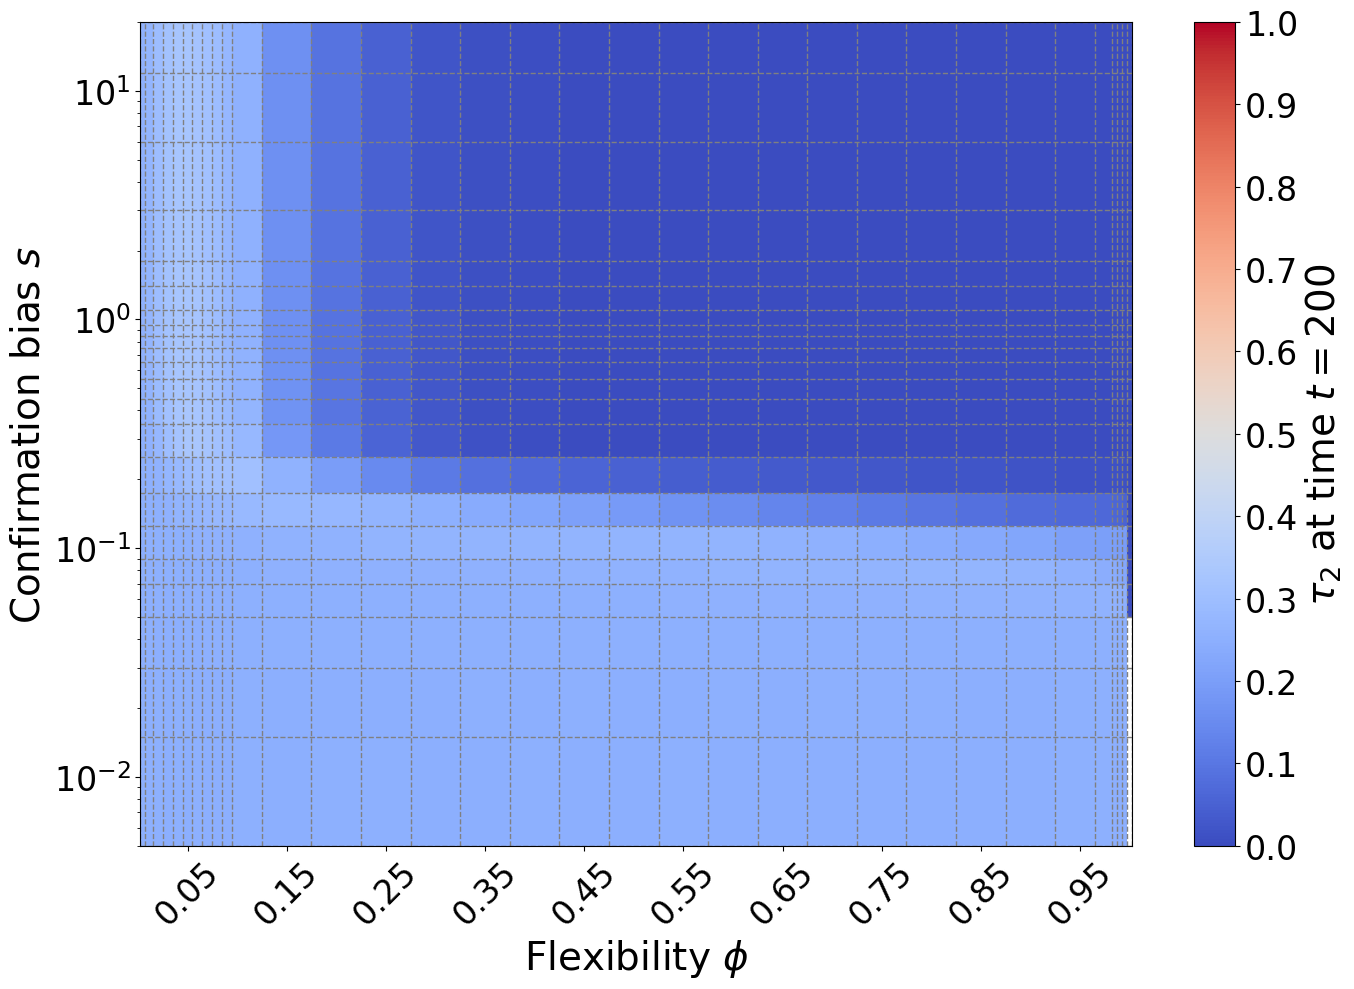

<Figure size 1400x1000 with 0 Axes>

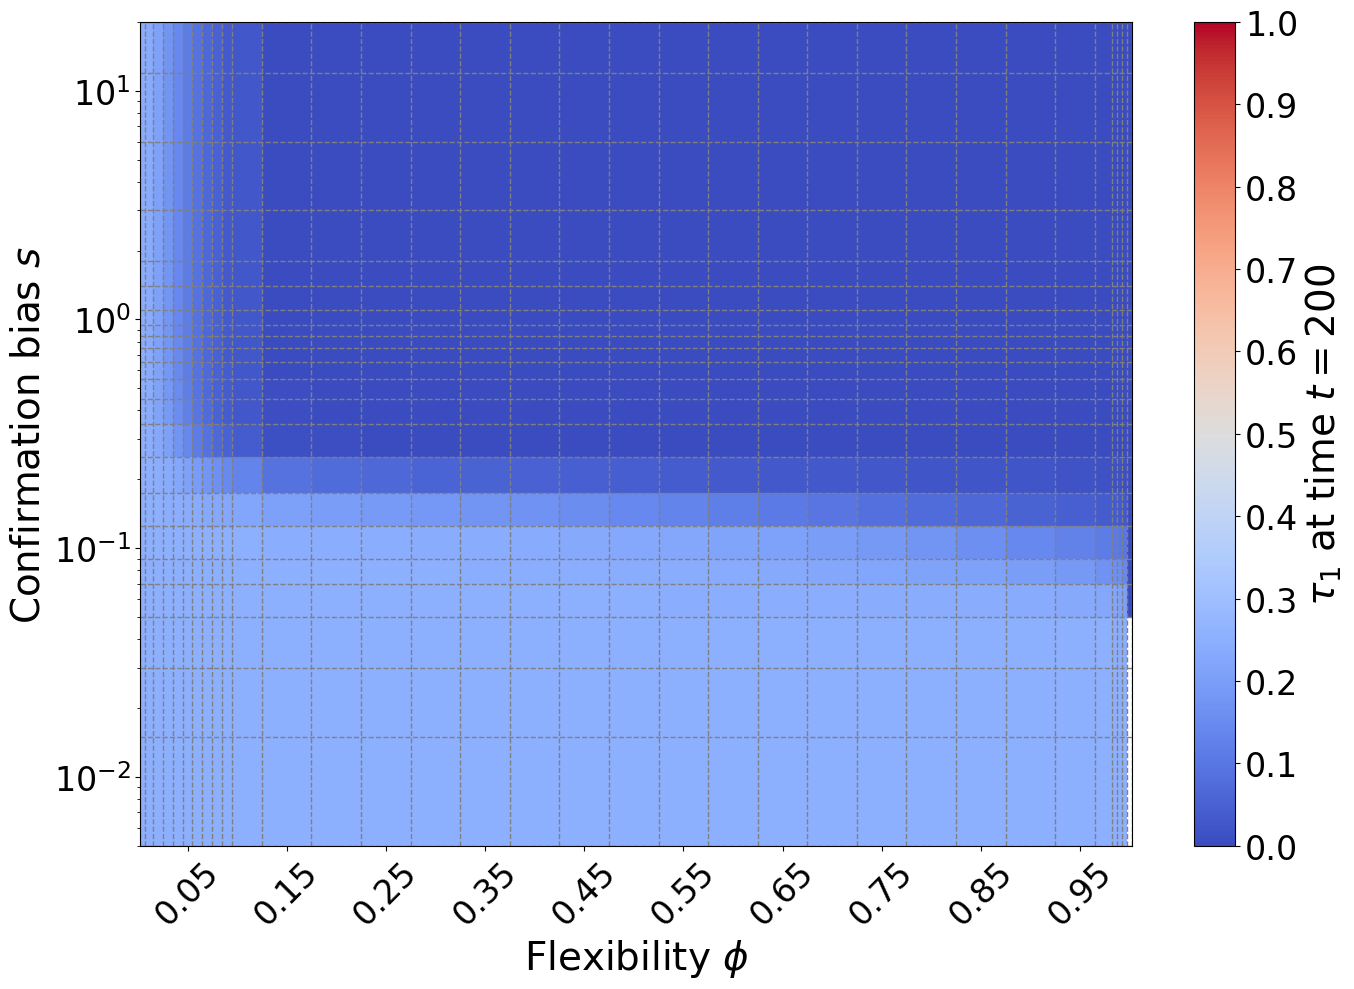

<Figure size 1400x1000 with 0 Axes>

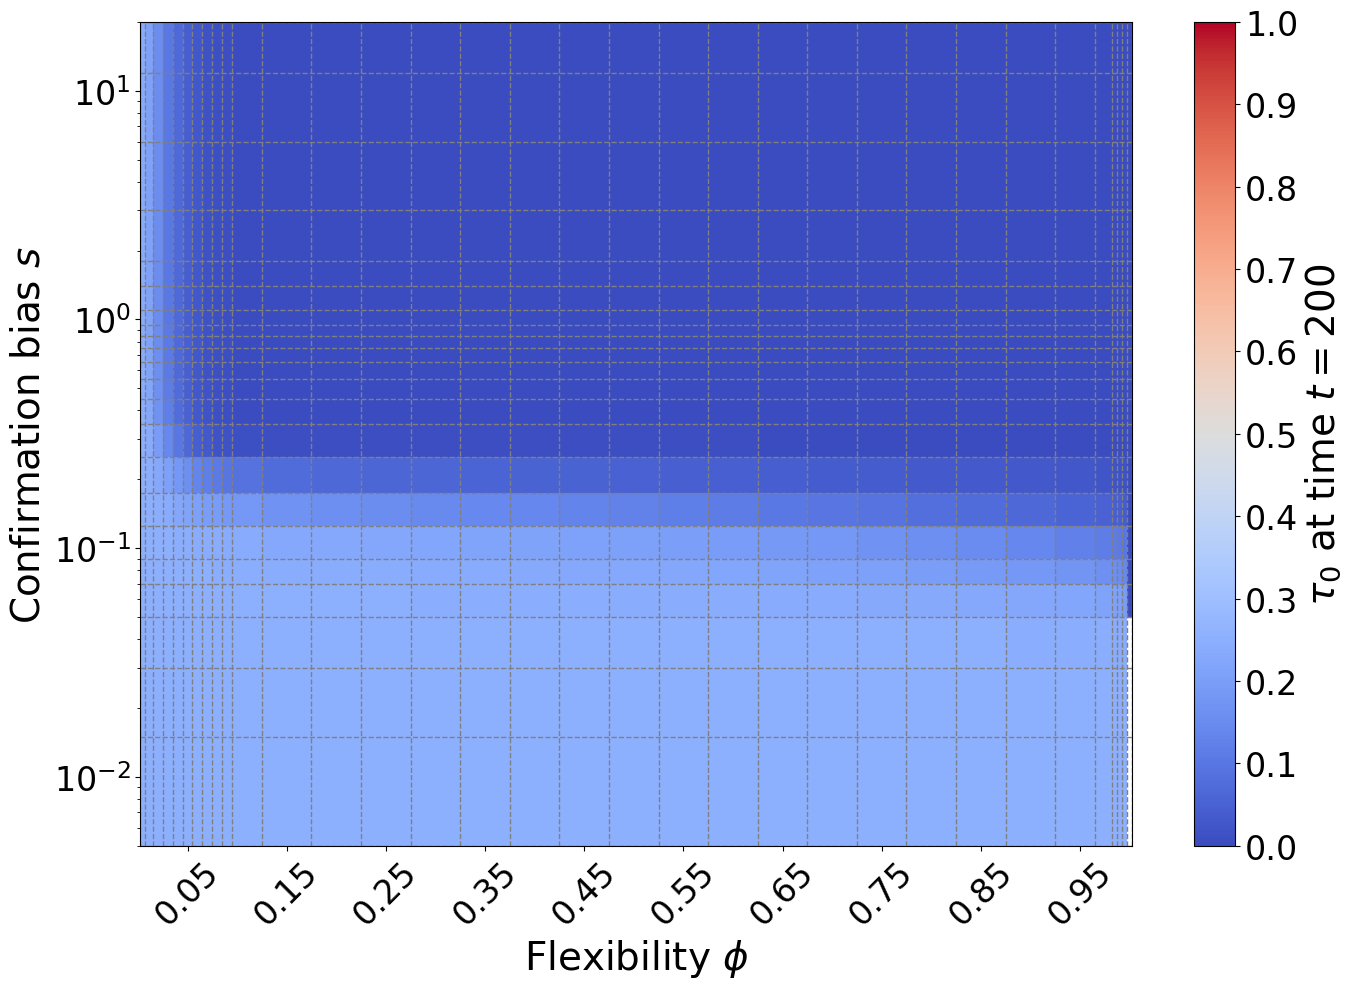

In [2]:
data_path = Path("combined_results/summary_square_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(data_path)

plot_cont_phase_diagram(df, "T3", Path(f"cont_phase_diagram_T3-0p24-1.png"), Path(r'plots'))
plot_cont_phase_diagram(df, "T3", Path(f"cont_phase_diagram_T3.png"), Path(r'plots'))
plot_cont_phase_diagram(df, "T2", Path(f"cont_phase_diagram_T2.png"), Path(r'plots'))
plot_cont_phase_diagram(df, "T1", Path(f"cont_phase_diagram_T1.png"), Path(r'plots'))
plot_cont_phase_diagram(df, "T0", Path(f"cont_phase_diagram_T0.png"), Path(r'plots'))


C:\Users\audso\AppData\Local\Temp\ipykernel_25856\3023011570.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1400x1000 with 0 Axes>

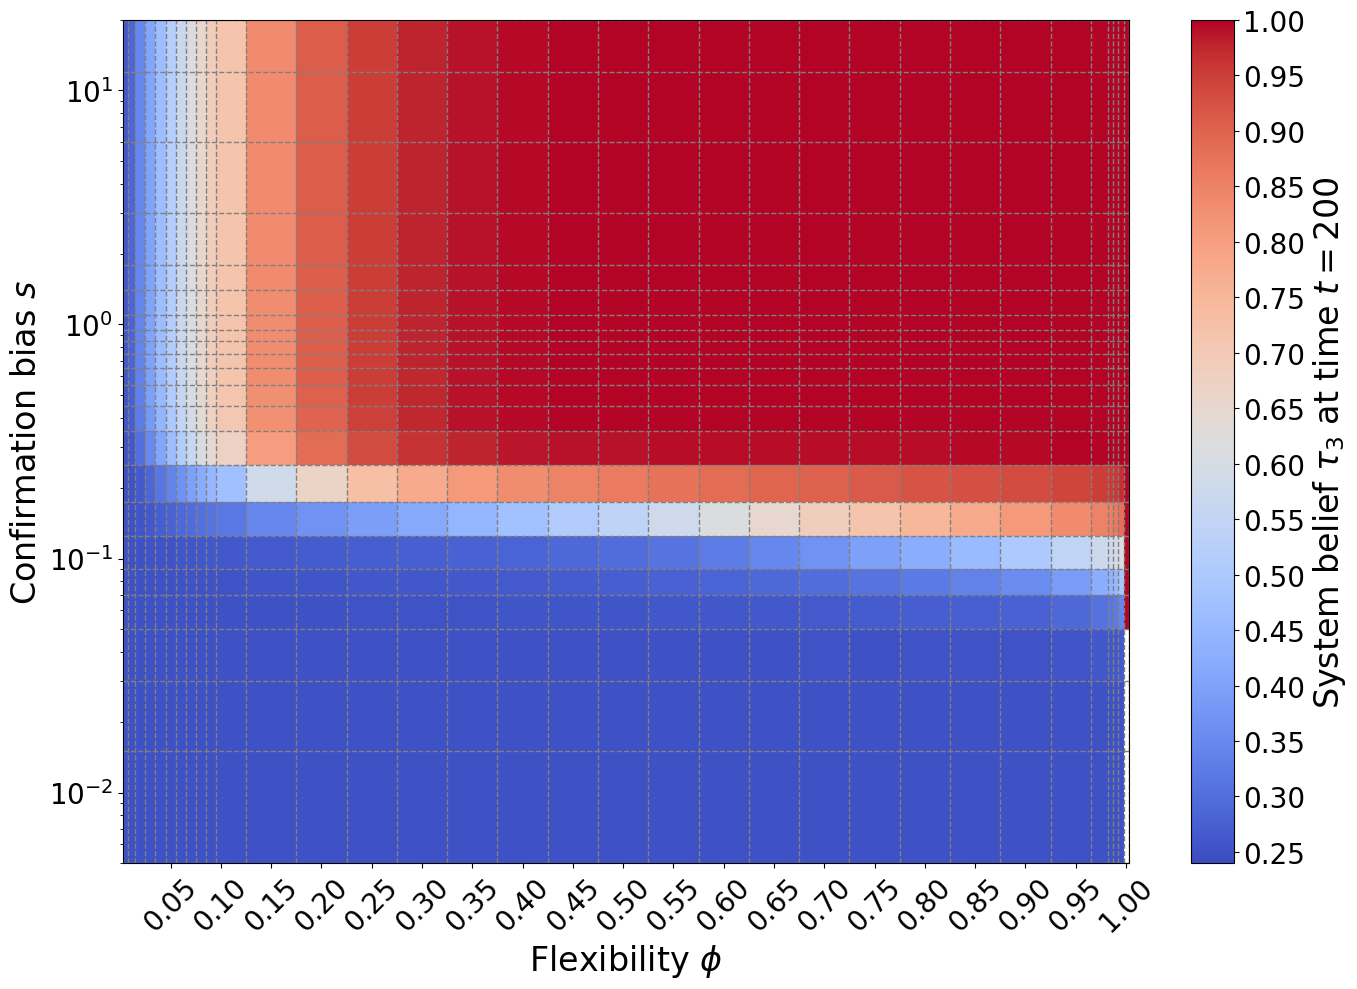

<Figure size 1400x1000 with 0 Axes>

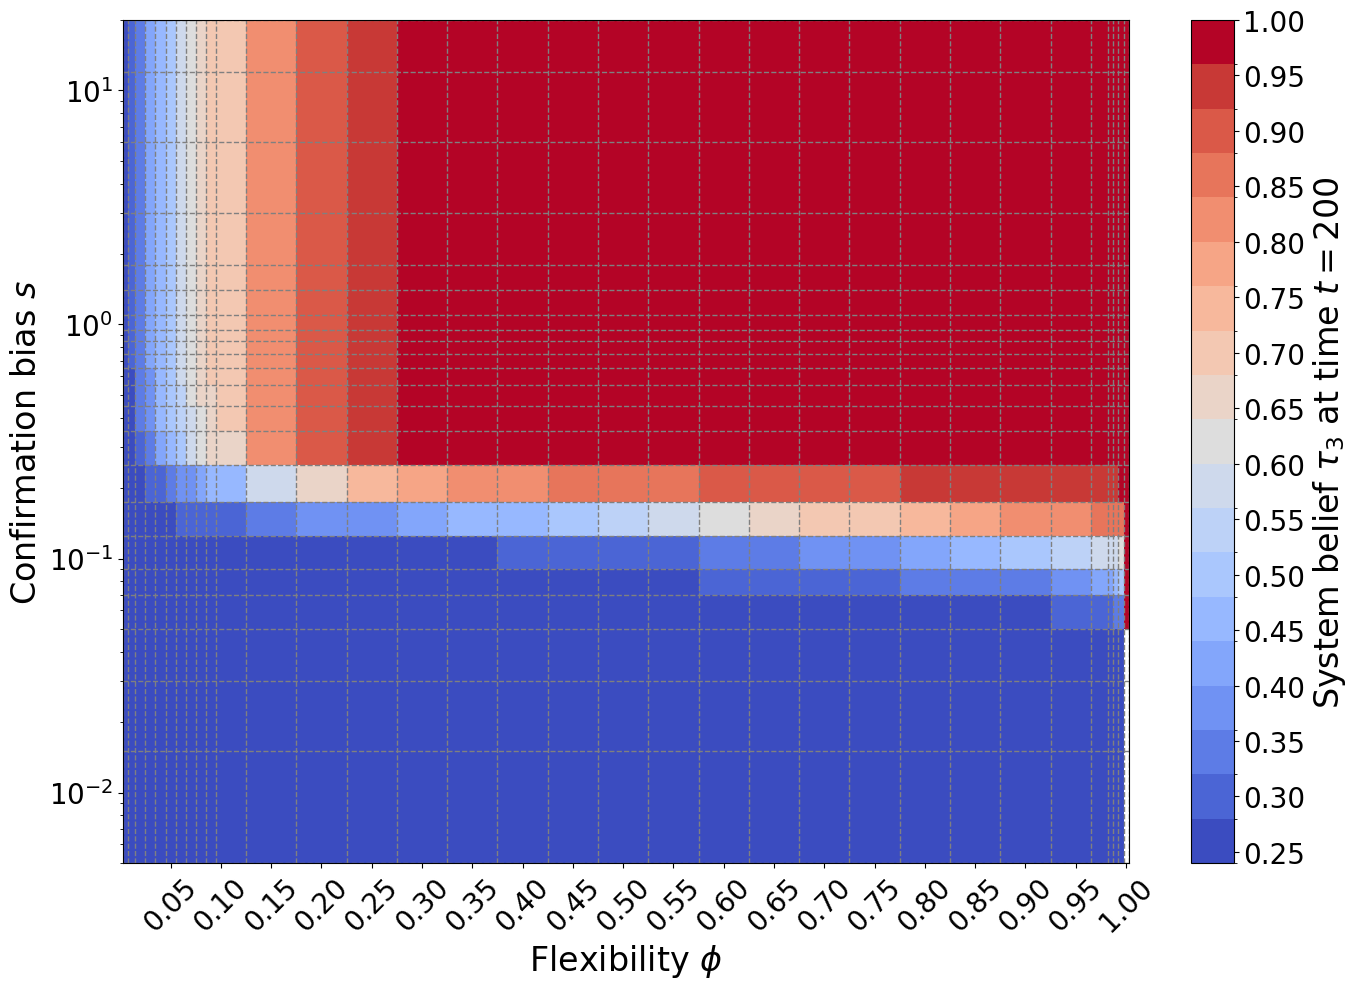

✅ Saved heatmap to plots\heatmap_logy_T3.png


In [3]:
data_path = Path("combined_results/summary_square_final.csv")  # adjust if needed
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

FLEX_STRENGTH_values = [
    0.005, 0.01, 0.02, 0.03, 0.04, 0.050, 0.06, 0.07, 0.08, 0.09,
    0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400,
    0.450, 0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800,
    0.850, 0.900, 0.950, 0.980, 0.985, 0.990, 0.995, 1.000
]
S_values = [
    0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.6, 2, 4, 8, 16
]
X, Y = np.meshgrid(FLEX_STRENGTH_values, S_values)

df = pd.read_csv(data_path)
metric = "T3" 
pivot = df.pivot(index="S", columns="F", values=metric)
pivot.index = pivot.index.astype(float)
pivot.columns = pivot.columns.astype(float)

vmin, vmax = 0.24, 1.0
n_bins = 19
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

pivot = pivot.sort_index(axis=0, ascending=False).sort_index(axis=1)

def compute_edges(arr):
    arr = np.asarray(arr)
    edges = (arr[:-1] + arr[1:]) / 2
    edges = np.concatenate([[arr[0] - (edges[0] - arr[0])], edges, [arr[-1] + (arr[-1] - edges[-1])]])
    return edges
y_ticks = [0.1, 0.6, 1.0, 2, 4, 8, 16]

plt.figure(figsize=(14, 10))
fig, ax = plt.subplots(figsize=(14, 10))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap="coolwarm",
    vmin=0.24,
    vmax=1.0,
    # cmap=cmap,
    # norm=norm,
    # shading="nearest"
)

for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=1)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=1)

cbar = fig.colorbar(mesh, ax=ax, ticks=[0.25 + i*0.05 for i in range(16)])
cbar.set_label(fr"System belief $\tau_3$ at time $t=200$", fontsize=24)
cbar.ax.tick_params(labelsize=20)
ax.set_yscale('log')
# ax.set_xscale('log')
# plt.title(fr"Heatmap of final belief $\tau_{metric[-1]}$")
plt.xlabel(r"Flexibility $\phi$", fontsize=24)
plt.ylabel(r"Confirmation bias $s$", fontsize=24)
plt.yticks(fontsize=20)
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=20, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"heatmap_logy_{metric}.png"
plt.savefig(out_path, dpi=400)
plt.show()


plt.figure(figsize=(14, 10))
fig, ax = plt.subplots(figsize=(14, 10))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)

for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=1)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=1)

cbar = fig.colorbar(mesh, ax=ax, ticks=[0.25 + i*0.05 for i in range(16)])
cbar.set_label(fr"System belief $\tau_3$ at time $t=200$", fontsize=24)
cbar.ax.tick_params(labelsize=20)
ax.set_yscale('log')
# ax.set_xscale('log')
# plt.title(fr"Heatmap of final belief $\tau_{metric[-1]}$")
plt.xlabel(r"Flexibility $\phi$", fontsize=24)
plt.ylabel(r"Confirmation bias $s$", fontsize=24)
plt.yticks(fontsize=20)
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=20, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
# out_path = output_dir / f"heatmap_logy_{metric}.png"
plt.savefig(out_path, dpi=400)
plt.show()

print(f"✅ Saved heatmap to {out_path}")

In [5]:
S_values = [0.01, 0.02, 0.04, 0.06, 0.08, 0.15]
FLEX_STRENGTH_values = [
    0.005, 0.01, 0.02, 0.03, 0.04, 0.050, 0.06, 0.07, 0.08, 0.09,
    0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400,
    0.450, 0.500, 0.550, 0.600, 0.650, 0.700, 0.750, 0.800,
    0.850, 0.900, 0.950, 0.980, 0.985, 0.990, 0.995, 1.000
]
print(len(FLEX_STRENGTH_values), len(S_values))
print(len(FLEX_STRENGTH_values)*len(S_values), len(FLEX_STRENGTH_values)*len(S_values)/6)

S_values = [
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.2, 1.6, 2, 4, 8, 16
]
FLEX_STRENGTH_values = [
    0.005, 0.01, 0.02, 0.03, 0.04, 0.06, 0.07, 0.08, 0.09
]
print(len(FLEX_STRENGTH_values), len(S_values))
print(len(FLEX_STRENGTH_values)*len(S_values), len(FLEX_STRENGTH_values)*len(S_values)/6)

33 6
198 33.0
9 16
144 24.0


Processing combined files:   0%|          | 0/726 [00:00<?, ?it/s]

Processing combined files: 100%|██████████| 726/726 [00:15<00:00, 45.49it/s]
C:\Users\audso\AppData\Local\Temp\ipykernel_38028\1121118275.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("coolwarm", n_bins)


<Figure size 1000x670 with 0 Axes>

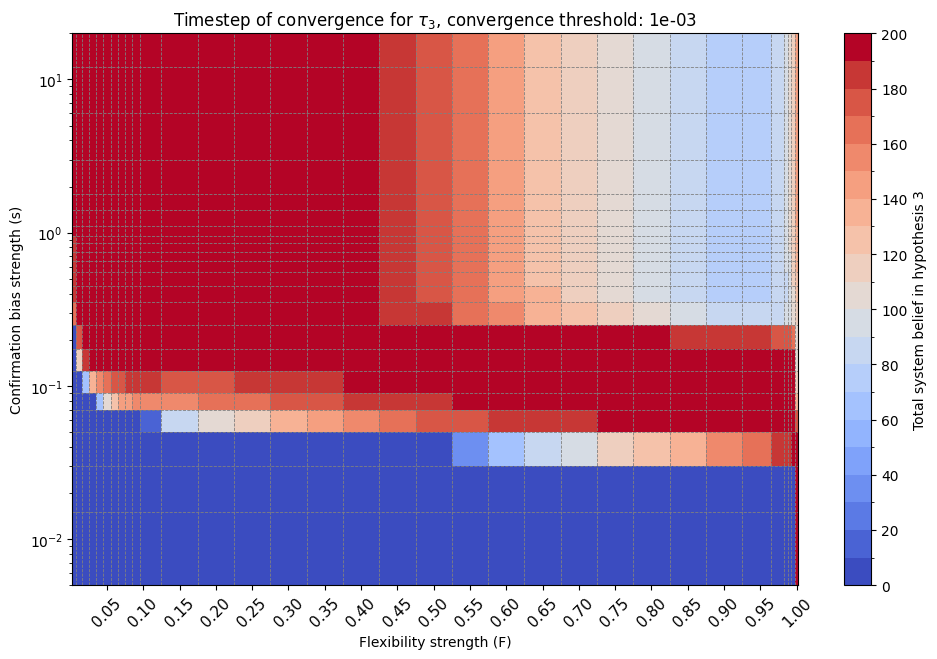

✅ Saved convergence heatmap to plots\convergence_1e-03_heatmap_T3.png


In [6]:
# === Configuration ===
data_root = Path("combined_results")
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True, parents=True)

metric = "T3"          # change to T1, T2, T3, or CD as needed
threshold = 1e-3       # convergence criterion
n_bins = 10            # discrete color levels
vmin, vmax = 0, 200    # timestep range for color scale (adjust to your simulation length)

# === Load all combined files ===
files = list(data_root.glob("COMBINED_S*_F*.npz"))
rows = []

for f in tqdm(files, desc="Processing combined files"):
    data = np.load(f)
    S, F = data["S"].item(), data["F"].item()
    arr = data[metric]
    final_val = arr[-1]

    # find first timestep within threshold of final value
    diffs = np.abs(arr - final_val)
    conv_idx = np.argmax(diffs < threshold) if np.any(diffs < threshold) else len(arr) - 1
    rows.append({"S": S, "F": F, "converged_at": conv_idx})

# === Build DataFrame ===
df = pd.DataFrame(rows)
pivot = df.pivot(index="S", columns="F", values="converged_at")
pivot = pivot.sort_index(axis=0).sort_index(axis=1)

# === Fixed discrete colormap ===
vmin, vmax = 0.0, 200
n_bins = 20
bounds = np.linspace(vmin, vmax, n_bins + 1)
cmap = cm.get_cmap("coolwarm", n_bins)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# === Plot ===
# plt.figure(figsize=(10, 6.7))
# sns.set_context("talk")

# ax = sns.heatmap(
#     pivot,
#     cmap="coolwarm",
#     vmin=np.min(df["converged_at"]),
#     vmax=np.max(df["converged_at"]),
#     # norm=norm,
#     cbar_kws={
#         "ticks": np.linspace(np.min(df["converged_at"]), 214, 15),
#         "label": f"t at convergence for belief in hypothesis {metric[1]}",
#     },
#     linewidths=0.1,
#     linecolor='black',
#     square=True
# )

# # plt.title(f"Heatmap of {metric} (final timestep)")
# plt.xlabel("Flexibility strength (F)")
# plt.ylabel("Confirmation bias strength (s)")
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.tight_layout()
# out_path = output_dir / f"convergence_heatmap_{metric}.png"
# plt.savefig(out_path, dpi=300)
# plt.show()

plt.figure(figsize=(10, 6.7))
fig, ax = plt.subplots(figsize=(10, 6.7))

# Convert pivot to numpy
Z = pivot.values
x = pivot.columns.values
y = pivot.index.values
x_edges = compute_edges(x)
y_edges = compute_edges(y)

mesh = ax.pcolormesh(
    x, y, Z,
    cmap=cmap,
    norm=norm,
    shading="nearest"
)
for xv in x_edges:
    ax.axvline(xv, color="gray", linestyle="--", linewidth=0.6)
for yv in y_edges:
    ax.axhline(yv, color="gray", linestyle="--", linewidth=0.6)

cbar = fig.colorbar(mesh, ax=ax, ticks=bounds[::2])
cbar.set_label(f"Total system belief in hypothesis {metric[1]}")

ax.set_yscale('log')
# ax.set_xscale('log')
plt.title(fr"Timestep of convergence for $\tau_{metric[-1]}$, convergence threshold: {threshold:.0e}")
plt.xlabel("Flexibility strength (F)")
plt.ylabel("Confirmation bias strength (s)")
plt.xticks(np.arange(0.05, 1.05, step=0.05), fontsize=11, rotation=45)
# plt.yticks(S_values, fontsize=11)
plt.tight_layout()
out_path = output_dir / f"convergence_{threshold:.0e}_heatmap_{metric}.png"
plt.savefig(out_path, dpi=300)
plt.show()

print(f"✅ Saved convergence heatmap to {out_path}")
